# Customer Feedback Sentiment Analysis and Insights Dashboard

This project analyzes customer comments to understand sentiment patterns, key complaint themes, and business insights.
A lightweight machine learning model is included to classify sentiment from text.

In [ ]:
# Imports
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load data 
df = pd.read_csv("sentiment_data.csv")
df.head()

,Unnamed: 0,Comment,Sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers don’t even contactless credit car...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesn’t take apple pay doesn...,0
4,4,apple pay convenient secure easy use used kore...,2


In [ ]:
df.shape

(241145, 3)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 241145 entries, 0 to 241144
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  241145 non-null  int64
 1   Comment     240928 non-null  str  
 2   Sentiment   241145 non-null  int64
dtypes: int64(2), str(1)
memory usage: 5.5 MB


In [ ]:
df.isnull().sum()

Unnamed: 0      0
Comment       217
Sentiment       0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower()
df.head()

,unnamed: 0,comment,sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers don’t even contactless credit car...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesn’t take apple pay doesn...,0
4,4,apple pay convenient secure easy use used kore...,2


In [ ]:
# Keep required columns
df = df[['comment', 'sentiment']]
df.head()

,comment,sentiment
0,lets forget apple pay required brand new iphon...,1
1,nz retailers don’t even contactless credit car...,0
2,forever acknowledge channel help lessons ideas...,2
3,whenever go place doesn’t take apple pay doesn...,0
4,apple pay convenient secure easy use used kore...,2


In [ ]:
# Drop missing and duplicate rows
df = df.dropna(subset=['comment', 'sentiment'])
df = df.drop_duplicates()
df.shape

(214333, 2)

In [ ]:
# Label mapping

label_map = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

df['sentiment_label'] = df['sentiment'].map(label_map)
df[['sentiment', 'sentiment_label']].head()

,sentiment,sentiment_label
0,1,Neutral
1,0,Negative
2,2,Positive
3,0,Negative
4,2,Positive


In [ ]:
# Clean text function

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
# Apply cleaning

df['clean_comment'] = df['comment'].apply(clean_text)
df[['comment', 'clean_comment']].head()

,comment,clean_comment
0,lets forget apple pay required brand new iphon...,lets forget apple pay required brand new iphon...
1,nz retailers don’t even contactless credit car...,nz retailers don t even contactless credit car...
2,forever acknowledge channel help lessons ideas...,forever acknowledge channel help lessons ideas...
3,whenever go place doesn’t take apple pay doesn...,whenever go place doesn t take apple pay doesn...
4,apple pay convenient secure easy use used kore...,apple pay convenient secure easy use used kore...


In [ ]:
# Remove empty cleaned comments

df = df[df['clean_comment'].str.len() > 0]
df.shape

(214067, 3)

In [ ]:
df.shape

(214067, 3)

# EDA

In [ ]:
# Sentiment counts

df['sentiment'].value_counts().sort_index()

sentiment
0    48302
1    71552
2    94213
Name: count, dtype: int64

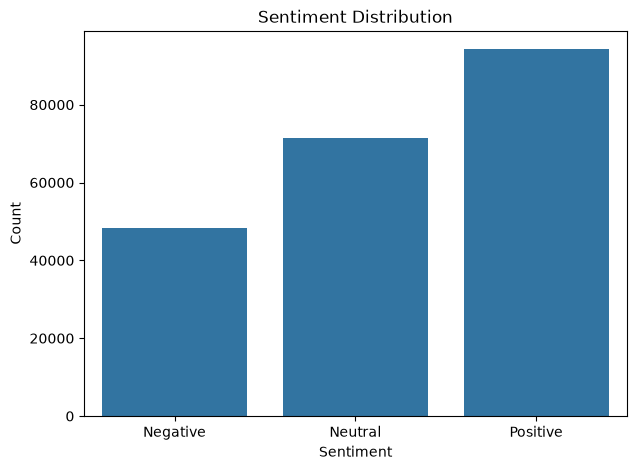

In [ ]:
# Sentiment distribution chart

plt.figure(figsize=(7,5))
sns.countplot(data=df, x='sentiment_label', order=['Negative', 'Neutral', 'Positive'])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [ ]:
# Comment length features

df['char_count'] = df['clean_comment'].str.len()
df['word_count'] = df['clean_comment'].str.split().apply(len)
df[['char_count', 'word_count']].describe()

,char_count,word_count
count,214067.000000,214067.000000
mean,92.136088,13.678428
std,72.750865,10.457962
min,1.000000,1.000000
25%,45.000000,7.000000
50%,77.000000,12.000000
75%,131.000000,19.000000
max,4659.000000,752.000000


In [ ]:
# Length by sentiment

df.groupby('sentiment_label')[['char_count', 'word_count']].mean()

,char_count,word_count
sentiment_label,,
Negative,103.268208,15.246180
Neutral,70.675257,10.638864
Positive,102.727638,15.183117


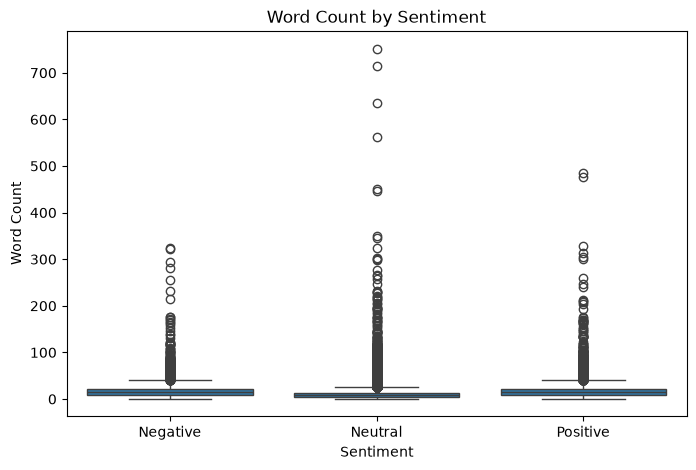

In [ ]:
# Word count boxplot

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='sentiment_label', y='word_count', order=['Negative', 'Neutral', 'Positive'])
plt.title("Word Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Word Count")
plt.show()

In [ ]:
# Top words overall

all_words = " ".join(df['clean_comment']).split()
top_words = Counter(all_words).most_common(20)
top_words

[('modi', 149473),
 ('india', 27917),
 ('like', 17785),
 ('people', 15317),
 ('bjp', 14140),
 ('one', 13026),
 ('congress', 12335),
 ('dont', 11094),
 ('narendra', 11037),
 ('time', 10717),
 ('govt', 9629),
 ('get', 9199),
 ('good', 9184),
 ('vote', 8968),
 ('even', 8414),
 ('years', 8190),
 ('know', 8170),
 ('also', 8112),
 ('would', 8007),
 ('country', 7752)]

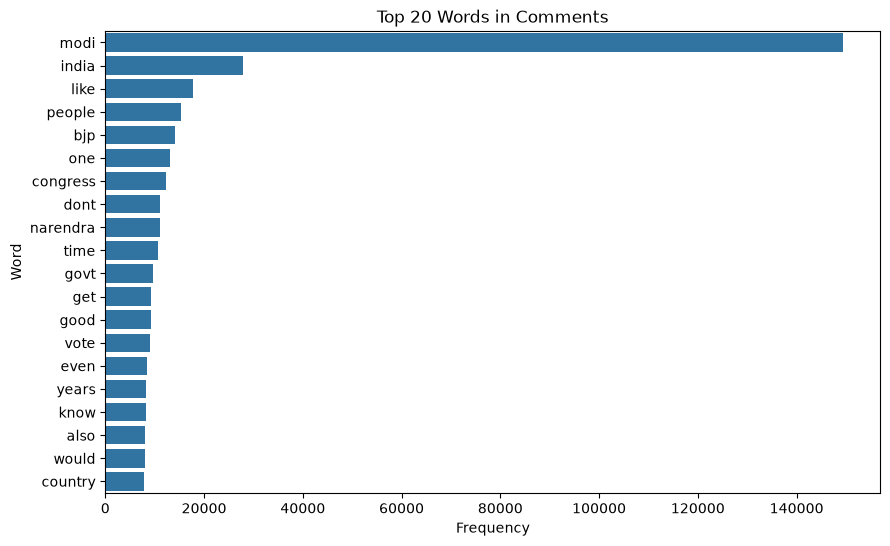

In [ ]:
# Top words chart

words = [w for w, c in top_words]
counts = [c for w, c in top_words]

plt.figure(figsize=(10,6))
sns.barplot(x=counts, y=words)
plt.title("Top 20 Words in Comments")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

In [ ]:
# Top words by sentiment

for s in ['Negative', 'Neutral', 'Positive']:
    subset = df[df['sentiment_label'] == s]['clean_comment']
    words = " ".join(subset).split()
    print(f"\nSentiment: {s}")
    display(pd.DataFrame(Counter(words).most_common(15), columns=['word', 'count']))


Sentiment: Negative


,word,count
0,modi,34081
1,india,6091
2,like,4639
3,people,4543
4,bjp,3492
5,congress,3337
6,dont,3319
7,one,3065
8,poor,2716
9,even,2663



Sentiment: Neutral


,word,count
0,modi,47280
1,india,6435
2,like,4494
3,narendra,3857
4,bjp,3829
5,congress,3404
6,people,3225
7,dont,3188
8,one,3133
9,vote,2880



Sentiment: Positive


,word,count
0,modi,68112
1,india,15391
2,like,8652
3,people,7549
4,good,7375
5,one,6828
6,bjp,6819
7,great,5839
8,congress,5594
9,time,5423


In [ ]:
# Define features and target

X = df['clean_comment']
y = df['sentiment']

In [ ]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
#  Logistic Regression model

lr_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf', LogisticRegression(max_iter=1000))
])

In [ ]:
# Train logistic model

lr_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",5000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


In [ ]:
# Predict and evaluate

y_pred_lr = lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7970056523567057
              precision    recall  f1-score   support

           0       0.79      0.65      0.71      9660
           1       0.75      0.85      0.80     14311
           2       0.84      0.83      0.84     18843

    accuracy                           0.80     42814
   macro avg       0.79      0.78      0.78     42814
weighted avg       0.80      0.80      0.80     42814



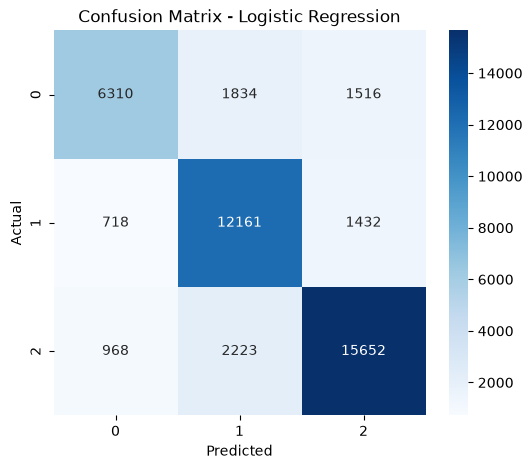

In [ ]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Naive Bayes model

nb_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf', MultinomialNB())
])

nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.6734012238987247
              precision    recall  f1-score   support

           0       0.78      0.44      0.56      9660
           1       0.68      0.60      0.64     14311
           2       0.65      0.85      0.74     18843

    accuracy                           0.67     42814
   macro avg       0.70      0.63      0.64     42814
weighted avg       0.69      0.67      0.66     42814



In [ ]:
# Compare models

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.797006
1,Naive Bayes,0.673401


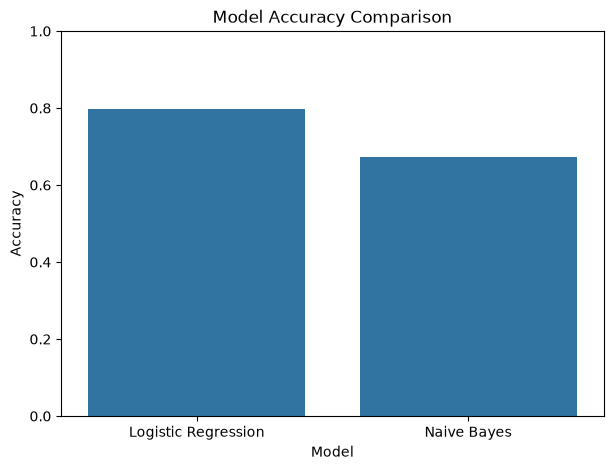

In [ ]:
# Model comparison chart

plt.figure(figsize=(7,5))
sns.barplot(data=results, x='Model', y='Accuracy')
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
#  Example predictions

sample_texts = [
    "this is very useful and convenient",
    "store does not accept payment and it is annoying",
    "okay experience nothing special",
    "I don't like this at all"
]

for text in sample_texts:
    pred = lr_model.predict([text])[0]
    label = label_map[pred]
    print(text, "=>", pred, "-", label)

this is very useful and convenient => 2 - Positive
store does not accept payment and it is annoying => 1 - Neutral
okay experience nothing special => 2 - Positive
I don't like this at all => 1 - Neutral


In [ ]:
# Save cleaned data

df.to_csv("cleaned_customer_feedback.csv", index=False)

## Conclusion

This project analyzed customer feedback to identify sentiment patterns, common complaint themes, and business insights.
A simple machine learning model was also built to classify comments into Negative, Neutral, and Positive sentiments.